In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, accuracy_score, 
                             precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


In [2]:
# Load the dataset directly (no chunking)
import time

print("="*60)
print("LOADING DATASET")
print("="*60)

start_time = time.time()

# Simple direct load
df = pd.read_csv('synthetic_fraud_data.csv')

load_time = time.time() - start_time

print(f"\n✓ Dataset loaded successfully in {load_time:.2f} seconds")
print(f"✓ Total rows: {len(df):,}")
print(f"✓ Total columns: {len(df.columns)}")
print(f"✓ Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
print("\n" + "="*60)
print("First 5 rows:")
print("="*60)
df.head()


LOADING DATASET

✓ Dataset loaded successfully in 102.53 seconds
✓ Total rows: 7,483,766
✓ Total columns: 24
✓ Memory usage: 8148.61 MB

First 5 rows:


,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,TX_a0ad2a2a,CUST_72886,6646734767813109,2024-09-30 00:00:01.034820+00:00,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,TX_3599c101,CUST_70474,376800864692727,2024-09-30 00:00:01.764464+00:00,Entertainment,gaming,Steam,3368.97,BRL,Brazil,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,TX_a9461c6d,CUST_10715,5251909460951913,2024-09-30 00:00:02.273762+00:00,Grocery,physical,Whole Foods,102582.38,JPY,Japan,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,TX_7be21fc4,CUST_16193,376079286931183,2024-09-30 00:00:02.297466+00:00,Gas,major,Exxon,630.60,AUD,Australia,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,TX_150f490b,CUST_87572,6172948052178810,2024-09-30 00:00:02.544063+00:00,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True


In [3]:
# Initial exploration
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found!")

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")

print("\n" + "="*60)
print("TARGET VARIABLE DISTRIBUTION")
print("="*60)
print(df['is_fraud'].value_counts())
print(f"\nFraud cases: {df['is_fraud'].sum():,} ({df['is_fraud'].mean()*100:.2f}%)")
print(f"Legitimate cases: {(~df['is_fraud']).sum():,} ({(1-df['is_fraud'].mean())*100:.2f}%)")


DATASET OVERVIEW

Dataset Shape: (7483766, 24)
Rows: 7,483,766 | Columns: 24

COLUMN NAMES
['transaction_id', 'customer_id', 'card_number', 'timestamp', 'merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'card_present', 'device', 'channel', 'device_fingerprint', 'ip_address', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'weekend_transaction', 'velocity_last_hour', 'is_fraud']

DATA TYPES
transaction_id          object
customer_id             object
card_number              int64
timestamp               object
merchant_category       object
merchant_type           object
merchant                object
amount                 float64
currency                object
country                 object
city                    object
city_size               object
card_type               object
card_present              bool
device                  object
channel                 object
device_fingerprint      obje

In [4]:
# Display basic statistics
print("="*60)
print("BASIC STATISTICS - NUMERICAL COLUMNS")
print("="*60)
df.describe()


BASIC STATISTICS - NUMERICAL COLUMNS


,card_number,amount,distance_from_home,transaction_hour
count,7.483766e+06,7.483766e+06,7.483766e+06,7.483766e+06
mean,4.222100e+15,4.792468e+04,3.220519e-01,1.215467e+01
std,2.341170e+15,1.775562e+05,4.672628e-01,6.536767e+00
min,3.700086e+14,1.000000e-02,0.000000e+00,0.000000e+00
25%,4.004400e+15,3.635300e+02,0.000000e+00,7.000000e+00
50%,5.010745e+15,1.177450e+03,0.000000e+00,1.200000e+01
75%,5.999914e+15,2.242953e+04,1.000000e+00,1.800000e+01
max,6.999728e+15,6.253153e+06,1.000000e+00,2.300000e+01


In [5]:
# OPTIMIZED DATA PREPROCESSING
# - Replaces columns instead of adding where possible
# - Drops unnecessary identifier columns
# - Memory efficient approach

print("="*60)
print("DATA PREPROCESSING (OPTIMIZED)")
print("="*60)

import time
start_time = time.time()

# Make a copy
df_processed = df.copy()
original_shape = df_processed.shape

print(f"\nOriginal dataset: {original_shape[0]:,} rows × {original_shape[1]} columns")

# ============================================================
# STEP 1: DROP UNNECESSARY COLUMNS (Before processing)
# ============================================================
print("\n" + "-"*60)
print("STEP 1: Dropping Unnecessary Columns")
print("-"*60)

columns_to_drop = {
    'transaction_id': 'Unique identifier - no predictive value',
    'customer_id': 'High cardinality - causes overfitting',
    'card_number': 'Sensitive PII - no fraud pattern',
    'device_fingerprint': 'Too unique (785K values) - causes overfitting',
    'ip_address': 'High cardinality (7.4M unique) - no direct pattern'
}

dropped_count = 0
for col, reason in columns_to_drop.items():
    if col in df_processed.columns:
        df_processed.drop(col, axis=1, inplace=True)
        print(f"   ❌ Dropped '{col}': {reason}")
        dropped_count += 1

print(f"\n   ✓ Dropped {dropped_count} identifier columns")

# ============================================================
# STEP 2: PROCESS TIMESTAMP (Extract features, then drop)
# ============================================================
print("\n" + "-"*60)
print("STEP 2: Processing Timestamp")
print("-"*60)

if 'timestamp' in df_processed.columns:
    # Convert to datetime
    df_processed['timestamp'] = pd.to_datetime(df_processed['timestamp'], errors='coerce')
    
    # Extract time-based features (MUST ADD - 1 column becomes 5)
    df_processed['hour'] = df_processed['timestamp'].dt.hour
    df_processed['day'] = df_processed['timestamp'].dt.day
    df_processed['month'] = df_processed['timestamp'].dt.month
    df_processed['day_of_week'] = df_processed['timestamp'].dt.dayofweek
    df_processed['is_night'] = ((df_processed['hour'] >= 22) | (df_processed['hour'] <= 6)).astype(int)
    
    # Drop original timestamp (now redundant)
    df_processed.drop('timestamp', axis=1, inplace=True)
    
    print("   ✓ Extracted: hour, day, month, day_of_week, is_night")
    print("   ❌ Dropped original 'timestamp' column (redundant)")

# ============================================================
# STEP 3: PROCESS VELOCITY (Replace JSON with numeric value)
# ============================================================
print("\n" + "-"*60)
print("STEP 3: Processing Velocity Metrics")
print("-"*60)

if 'velocity_last_hour' in df_processed.columns:
    def safe_parse_velocity(x):
        """Safely parse velocity JSON string to extract num_transactions"""
        try:
            if pd.isna(x) or x == '':
                return 0
            data = eval(str(x))
            return data.get('num_transactions', 0)
        except:
            return 0
    
    # REPLACE original column with parsed value
    df_processed['velocity_last_hour'] = df_processed['velocity_last_hour'].apply(safe_parse_velocity)
    
    # Rename for clarity
    df_processed.rename(columns={'velocity_last_hour': 'velocity_num_trans'}, inplace=True)
    
    print("   ✓ Parsed JSON and replaced with 'velocity_num_trans'")

# ============================================================
# STEP 4: ENCODE CATEGORICAL VARIABLES (Replace in-place)
# ============================================================
print("\n" + "-"*60)
print("STEP 4: Encoding Categorical Variables")
print("-"*60)

categorical_cols = ['merchant_type', 'merchant', 'currency', 'country', 
                   'merchant_category', 'channel', 'card_type', 'device',
                   'city', 'city_size']

label_encoders = {}
encoded_count = 0

for col in categorical_cols:
    if col in df_processed.columns:
        le = LabelEncoder()
        # REPLACE original column with encoded values (not adding new column)
        original_unique = df_processed[col].nunique()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
        print(f"   ✓ Encoded '{col}': {original_unique:,} unique values → numeric")
        encoded_count += 1

print(f"\n   ✓ Encoded {encoded_count} categorical columns (replaced in-place)")

# ============================================================
# STEP 5: CONVERT BOOLEAN COLUMNS (In-place conversion)
# ============================================================
print("\n" + "-"*60)
print("STEP 5: Converting Boolean Columns")
print("-"*60)

bool_cols = ['high_risk_merchant', 'weekend_transaction', 'card_present', 'is_fraud']
converted_count = 0

for col in bool_cols:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].astype(int)
        print(f"   ✓ Converted '{col}': True/False → 1/0")
        converted_count += 1

print(f"\n   ✓ Converted {converted_count} boolean columns to integers")

# ============================================================
# STEP 6: CREATE FRAUD INDICATORS (Must add - derived features)
# ============================================================
print("\n" + "-"*60)
print("STEP 6: Creating Fraud Indicator Features")
print("-"*60)

# Amount-based anomaly detection
amount_mean = df_processed['amount'].mean()
amount_std = df_processed['amount'].std()

df_processed['amount_zscore'] = (df_processed['amount'] - amount_mean) / amount_std
df_processed['is_large_amount'] = (df_processed['amount_zscore'].abs() > 3).astype(int)
df_processed['is_small_amount'] = (df_processed['amount'] < 1).astype(int)

print(f"   ✓ Created 'amount_zscore': Measures how unusual the amount is")
print(f"   ✓ Created 'is_large_amount': Flags transactions > 3 std deviations")
print(f"   ✓ Created 'is_small_amount': Flags suspiciously small amounts (<1)")

# Card not present indicator (online transactions = higher risk)
if 'card_present' in df_processed.columns:
    df_processed['card_not_present'] = (df_processed['card_present'] == 0).astype(int)
    print(f"   ✓ Created 'card_not_present': Flags online/phone transactions")

print(f"\n   ✓ Created 4 fraud indicator features")

# ============================================================
# STEP 7: HANDLE MISSING & INFINITE VALUES
# ============================================================
print("\n" + "-"*60)
print("STEP 7: Handling Missing & Infinite Values")
print("-"*60)

# Check for missing values
missing_count = df_processed.isnull().sum().sum()
if missing_count > 0:
    print(f"   ⚠ Found {missing_count:,} missing values")
    # Fill with median for numeric columns
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    df_processed[numeric_cols] = df_processed[numeric_cols].fillna(df_processed[numeric_cols].median())
    print(f"   ✓ Filled missing values with median")
else:
    print(f"   ✓ No missing values found")

# Check for infinite values
inf_count = np.isinf(df_processed.select_dtypes(include=[np.number]).values).sum()
if inf_count > 0:
    print(f"   ⚠ Found {inf_count:,} infinite values")
    df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    df_processed[numeric_cols] = df_processed[numeric_cols].fillna(df_processed[numeric_cols].median())
    print(f"   ✓ Replaced infinite values with median")
else:
    print(f"   ✓ No infinite values found")

# ============================================================
# SUMMARY
# ============================================================
elapsed_time = time.time() - start_time

print("\n" + "="*60)
print("PREPROCESSING COMPLETED!")
print("="*60)

print(f"\n📊 Dataset Transformation Summary:")
print(f"   ┌─────────────────────────────────────────────┐")
print(f"   │ Original shape:  {original_shape[0]:>10,} × {original_shape[1]:<3}        │")
print(f"   │ Final shape:     {df_processed.shape[0]:>10,} × {df_processed.shape[1]:<3}        │")
print(f"   │ Columns dropped: {original_shape[1] - df_processed.shape[1] + 4:>10}              │")
print(f"   │ Columns added:   {4:>10}              │")
print(f"   └─────────────────────────────────────────────┘")

print(f"\n⏱️  Processing time: {elapsed_time:.2f} seconds")

print(f"\n📋 Final Columns ({df_processed.shape[1]}):")
for i, col in enumerate(df_processed.columns, 1):
    print(f"   {i:2}. {col}")

# Memory usage
memory_mb = df_processed.memory_usage(deep=True).sum() / 1024**2
print(f"\n💾 Memory usage: {memory_mb:.2f} MB")


DATA PREPROCESSING (OPTIMIZED)

Original dataset: 7,483,766 rows × 24 columns

------------------------------------------------------------
STEP 1: Dropping Unnecessary Columns
------------------------------------------------------------
   ❌ Dropped 'transaction_id': Unique identifier - no predictive value
   ❌ Dropped 'customer_id': High cardinality - causes overfitting
   ❌ Dropped 'card_number': Sensitive PII - no fraud pattern
   ❌ Dropped 'device_fingerprint': Too unique (785K values) - causes overfitting
   ❌ Dropped 'ip_address': High cardinality (7.4M unique) - no direct pattern

   ✓ Dropped 5 identifier columns

------------------------------------------------------------
STEP 2: Processing Timestamp
------------------------------------------------------------
   ✓ Extracted: hour, day, month, day_of_week, is_night
   ❌ Dropped original 'timestamp' column (redundant)

------------------------------------------------------------
STEP 3: Processing Velocity Metrics
-----------

EXPLORATORY DATA ANALYSIS


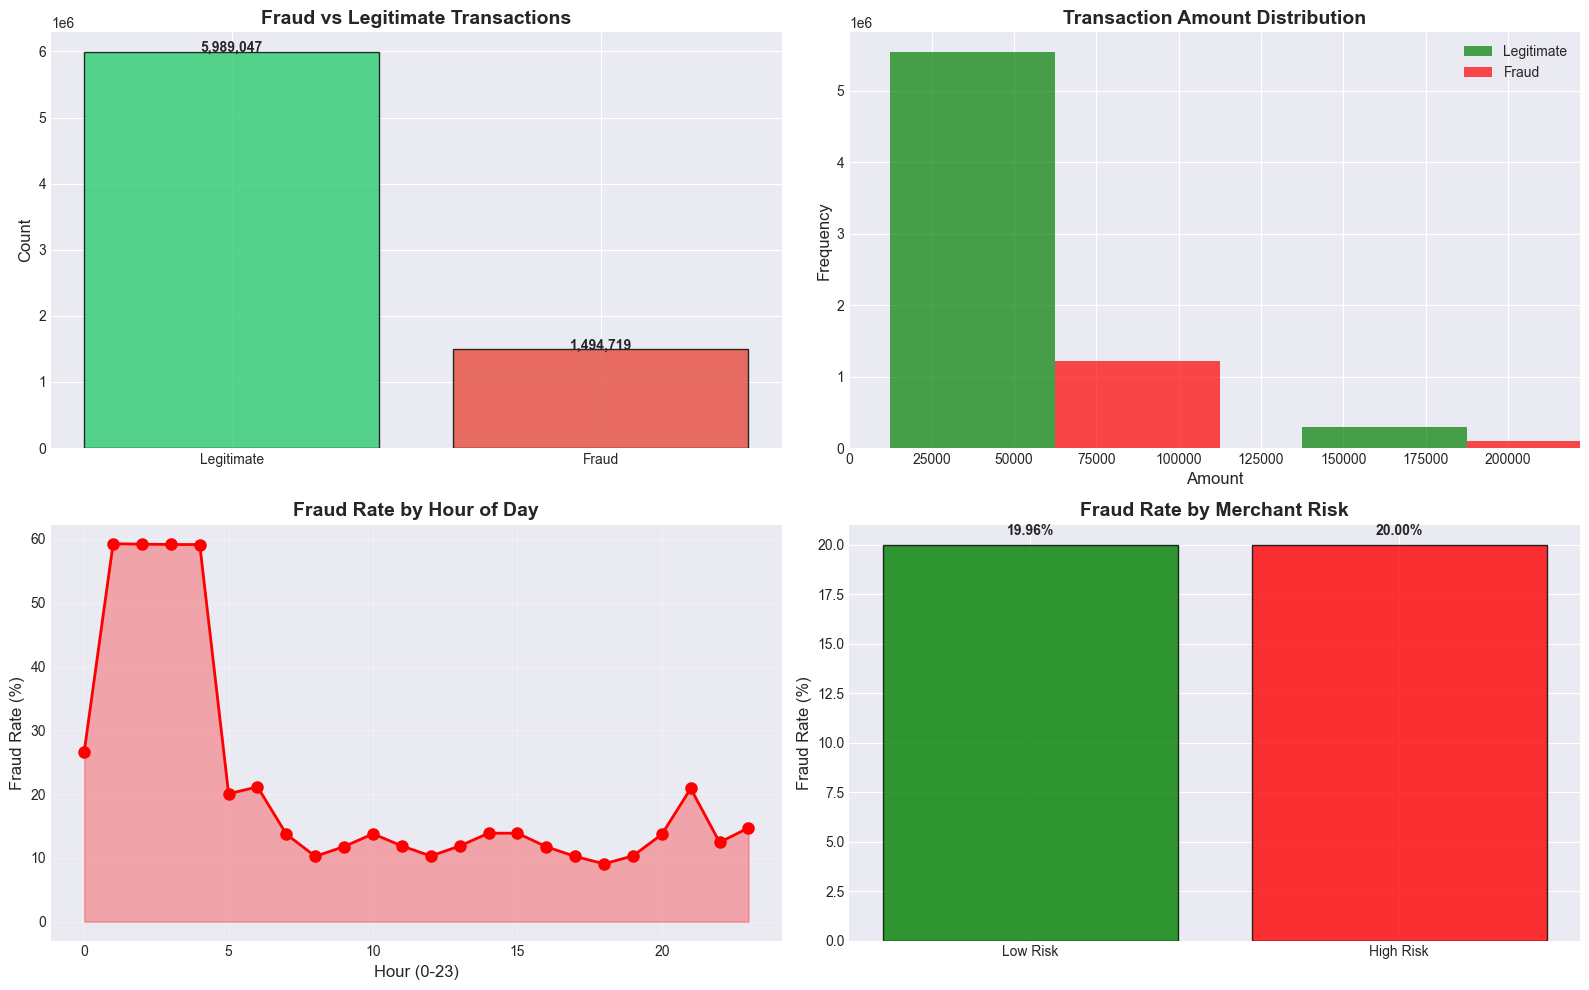


✓ Fraud analysis visualizations saved!


In [6]:
# EDA - Fraud Distribution
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure for fraud distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Fraud vs Legitimate
fraud_counts = df_processed['is_fraud'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0, 0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Fraud vs Legitimate Transactions', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(fraud_counts.values):
    axes[0, 0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 2. Amount Distribution
axes[0, 1].hist([df_processed[df_processed['is_fraud']==0]['amount'], 
                 df_processed[df_processed['is_fraud']==1]['amount']], 
                bins=50, label=['Legitimate', 'Fraud'], alpha=0.7, color=['green', 'red'])
axes[0, 1].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Amount', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].legend()
axes[0, 1].set_xlim(0, df_processed['amount'].quantile(0.95))

# 3. Fraud Rate by Hour
if 'hour' in df_processed.columns:
    hour_data = df_processed.groupby('hour')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
    axes[1, 0].plot(hour_data['hour'], hour_data['mean']*100, marker='o', linewidth=2, 
                    markersize=8, color='red')
    axes[1, 0].fill_between(hour_data['hour'], hour_data['mean']*100, alpha=0.3, color='red')
    axes[1, 0].set_title('Fraud Rate by Hour of Day', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Hour (0-23)', fontsize=12)
    axes[1, 0].set_ylabel('Fraud Rate (%)', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

# 4. High Risk Merchant
if 'high_risk_merchant' in df_processed.columns:
    risk_fraud = df_processed.groupby('high_risk_merchant')['is_fraud'].mean() * 100
    axes[1, 1].bar(['Low Risk', 'High Risk'], risk_fraud.values, 
                   color=['green', 'red'], alpha=0.8, edgecolor='black')
    axes[1, 1].set_title('Fraud Rate by Merchant Risk', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Fraud Rate (%)', fontsize=12)
    for i, v in enumerate(risk_fraud.values):
        axes[1, 1].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_fraud_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Fraud analysis visualizations saved!")


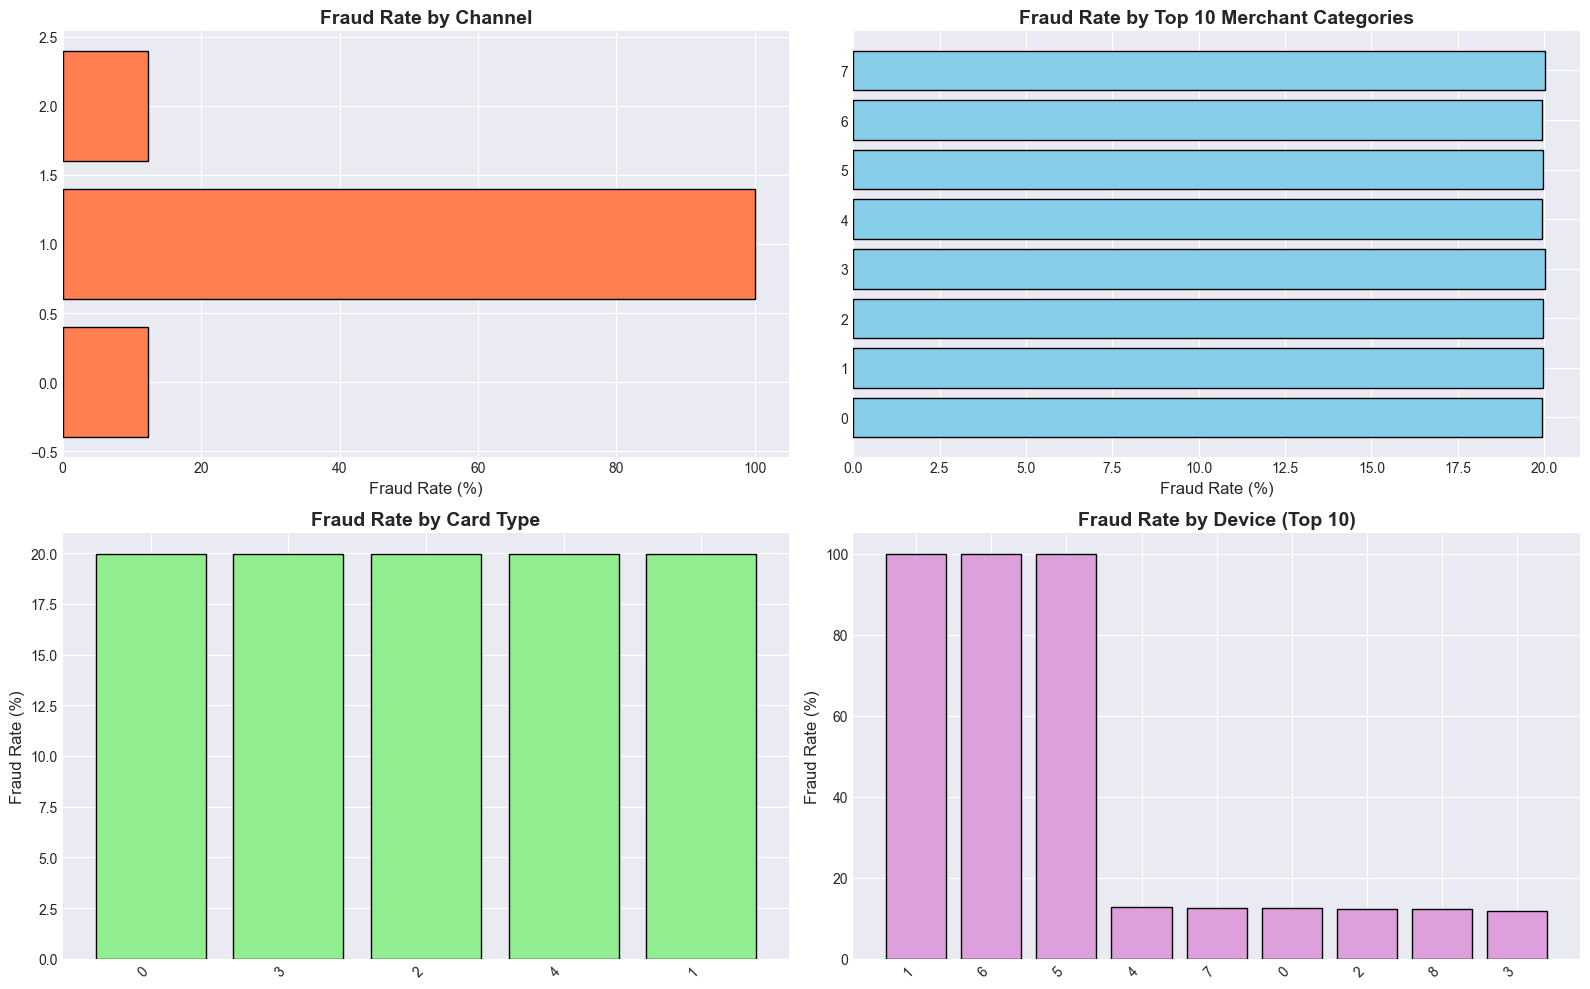


✓ Categorical analysis visualizations saved!


In [7]:
# EDA - Categorical Features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Channel Analysis
if 'channel' in df_processed.columns:
    channel_fraud = df_processed.groupby('channel')['is_fraud'].mean().sort_values(ascending=False) * 100
    axes[0, 0].barh(channel_fraud.index, channel_fraud.values, color='coral', edgecolor='black')
    axes[0, 0].set_title('Fraud Rate by Channel', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Fraud Rate (%)', fontsize=12)

# 2. Merchant Category
if 'merchant_category' in df_processed.columns:
    top_categories = df_processed['merchant_category'].value_counts().head(10).index
    cat_fraud = df_processed[df_processed['merchant_category'].isin(top_categories)]\
                .groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False) * 100
    axes[0, 1].barh(cat_fraud.index, cat_fraud.values, color='skyblue', edgecolor='black')
    axes[0, 1].set_title('Fraud Rate by Top 10 Merchant Categories', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Fraud Rate (%)', fontsize=12)

# 3. Card Type
if 'card_type' in df_processed.columns:
    card_fraud = df_processed.groupby('card_type')['is_fraud'].mean().sort_values(ascending=False) * 100
    axes[1, 0].bar(range(len(card_fraud)), card_fraud.values, color='lightgreen', edgecolor='black')
    axes[1, 0].set_xticks(range(len(card_fraud)))
    axes[1, 0].set_xticklabels(card_fraud.index, rotation=45, ha='right')
    axes[1, 0].set_title('Fraud Rate by Card Type', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Fraud Rate (%)', fontsize=12)

# 4. Device Type
if 'device' in df_processed.columns:
    device_fraud = df_processed.groupby('device')['is_fraud'].mean().sort_values(ascending=False).head(10) * 100
    axes[1, 1].bar(range(len(device_fraud)), device_fraud.values, color='plum', edgecolor='black')
    axes[1, 1].set_xticks(range(len(device_fraud)))
    axes[1, 1].set_xticklabels(device_fraud.index, rotation=45, ha='right')
    axes[1, 1].set_title('Fraud Rate by Device (Top 10)', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Fraud Rate (%)', fontsize=12)

plt.tight_layout()
plt.savefig('eda_categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Categorical analysis visualizations saved!")


CORRELATION ANALYSIS


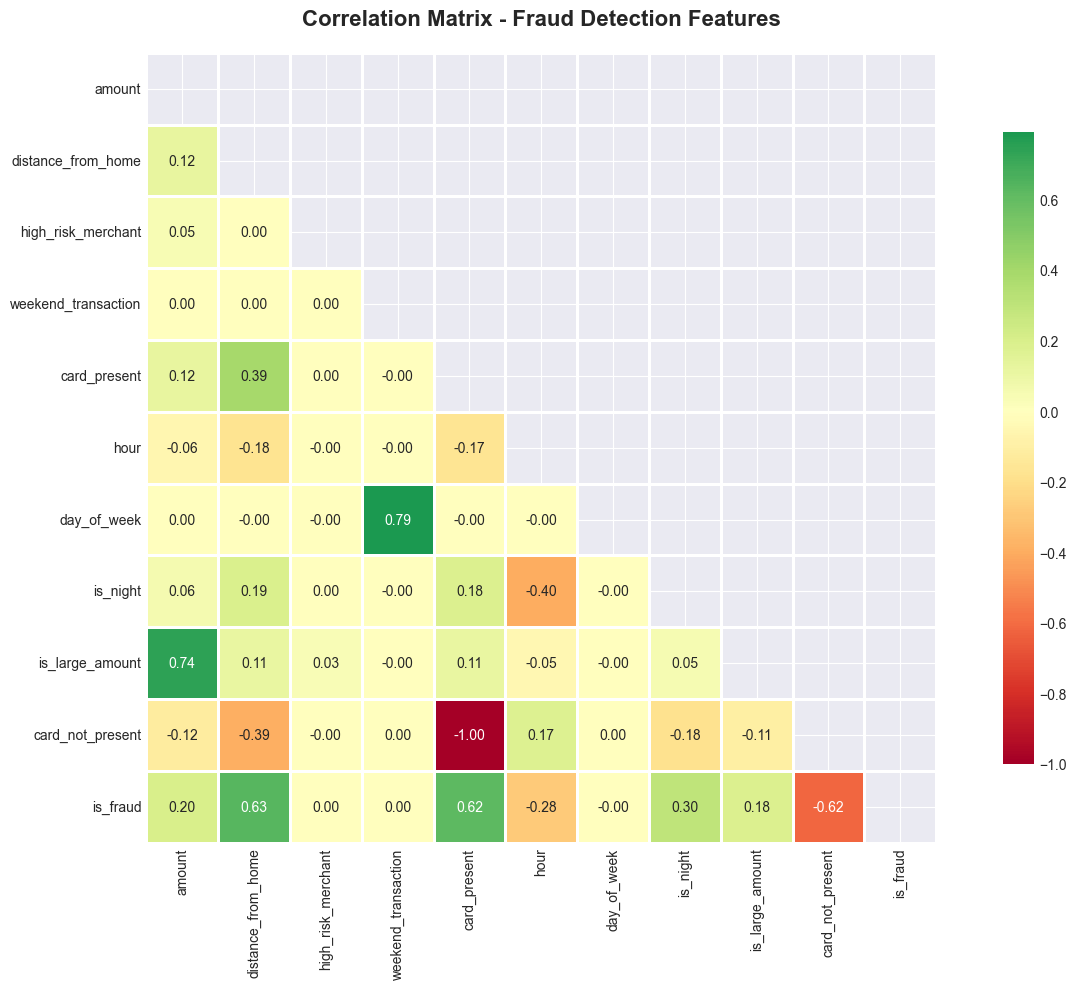


Top features correlated with fraud:
distance_from_home     0.634459
card_present           0.617886
is_night               0.299215
amount                 0.199342
is_large_amount        0.179706
high_risk_merchant     0.000373
weekend_transaction    0.000026
day_of_week           -0.000008
hour                  -0.279623
card_not_present      -0.617886
Name: is_fraud, dtype: float64


In [8]:
# Correlation Analysis
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Select numerical features for correlation
numerical_features = ['amount', 'distance_from_home', 'high_risk_merchant', 
                     'weekend_transaction', 'card_present', 'hour', 'day_of_week',
                     'is_night', 'is_large_amount', 'is_far_from_home', 
                     'card_not_present', 'is_fraud']

# Filter only existing columns
numerical_features = [col for col in numerical_features if col in df_processed.columns]

# Calculate correlation
corr_matrix = df_processed[numerical_features].corr()

# Create correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Fraud Detection Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top correlations with fraud
print("\nTop features correlated with fraud:")
fraud_corr = corr_matrix['is_fraud'].sort_values(ascending=False)
print(fraud_corr[fraud_corr.index != 'is_fraud'].head(10))


In [10]:
# Prepare features for modeling
print("="*60)
print("FEATURE PREPARATION FOR MODELING")
print("="*60)

# Define feature columns
feature_cols = []

# 1. Numerical features
numerical_features = ['amount', 'distance_from_home', 'velocity_num_trans', 
                     'amount_zscore', 'transaction_hour']
feature_cols.extend([col for col in numerical_features if col in df_processed.columns])

# 2. Encoded categorical features
encoded_features = [col for col in df_processed.columns if col.endswith('_encoded')]
feature_cols.extend(encoded_features)

# 3. Binary features
binary_features = ['high_risk_merchant', 'weekend_transaction', 'card_present',
                  'is_night', 'is_large_amount', 'is_far_from_home', 
                  'card_not_present', 'is_small_amount', 'is_weekend']
feature_cols.extend([col for col in binary_features if col in df_processed.columns])

# 4. Time features
time_features = ['hour', 'day', 'month', 'day_of_week']
feature_cols.extend([col for col in time_features if col in df_processed.columns])

# Remove duplicates
feature_cols = list(set(feature_cols))

print(f"\n✓ Total features selected: {len(feature_cols)}")
print(f"\n Feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i}. {col}")

# Prepare X and y
X = df_processed[feature_cols]
y = df_processed['is_fraud']

print(f"\n✓ X shape: {X.shape}")
print(f"✓ y shape: {y.shape}")
print(f"✓ Feature matrix memory: {X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


FEATURE PREPARATION FOR MODELING

✓ Total features selected: 16

 Feature list:
   1. card_present
   2. is_large_amount
   3. month
   4. card_not_present
   5. is_small_amount
   6. distance_from_home
   7. amount
   8. transaction_hour
   9. amount_zscore
   10. high_risk_merchant
   11. day
   12. hour
   13. is_night
   14. weekend_transaction
   15. day_of_week
   16. velocity_num_trans

✓ X shape: (7483766, 16)
✓ y shape: (7483766,)
✓ Feature matrix memory: 913.55 MB


In [11]:
# Split data into Train-Dev-Test (60:20:20)
print("="*60)
print("TRAIN-DEV-TEST SPLIT (60:20:20)")
print("="*60)

# Step 1: Split into 60% train and 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.40,      # 40% for dev + test
    random_state=42, 
    stratify=y
)

# Step 2: Split temp into 50% dev and 50% test (each becomes 20% of total)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50,      # 50% of 40% = 20% of total
    random_state=42, 
    stratify=y_temp
)

print(f"\n✓ Dataset Split Summary:")
print(f"   ┌─────────────────────────────────────────────────┐")
print(f"   │ Training set:   {len(X_train):>10,} samples ({len(X_train)/len(X)*100:>5.1f}%) │")
print(f"   │ Validation set: {len(X_dev):>10,} samples ({len(X_dev)/len(X)*100:>5.1f}%) │")
print(f"   │ Test set:       {len(X_test):>10,} samples ({len(X_test)/len(X)*100:>5.1f}%) │")
print(f"   └─────────────────────────────────────────────────┘")

print(f"\n✓ Fraud Distribution Across Sets:")
print(f"   Training   - Fraud: {y_train.sum():>10,} ({y_train.mean()*100:.2f}%)")
print(f"   Validation - Fraud: {y_dev.sum():>10,} ({y_dev.mean()*100:.2f}%)")
print(f"   Test       - Fraud: {y_test.sum():>10,} ({y_test.mean()*100:.2f}%)")

# Check for missing values before scaling
print("\n" + "-"*60)
print("Checking for missing values...")
print("-"*60)
nan_counts = X_train.isna().sum()
if nan_counts.sum() > 0:
    print("⚠ Missing values found:")
    print(nan_counts[nan_counts > 0])
    
    # Fill missing values
    print("\nFilling missing values...")
    train_median = X_train.median()
    X_train = X_train.fillna(train_median)
    X_dev = X_dev.fillna(train_median)      # Use train median
    X_test = X_test.fillna(train_median)    # Use train median
    print("✓ Missing values filled with training set median")
else:
    print("✓ No missing values found")

# Check for infinite values
print("\nChecking for infinite values...")
inf_count = np.isinf(X_train.values).sum()
if inf_count > 0:
    print(f"⚠ {inf_count} infinite values found, replacing...")
    train_median = X_train.median()
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(train_median)
    X_dev = X_dev.replace([np.inf, -np.inf], np.nan).fillna(train_median)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(train_median)
    print("✓ Infinite values handled")
else:
    print("✓ No infinite values found")

# Scale features
print("\n" + "-"*60)
print("Scaling features...")
print("-"*60)
scaler = StandardScaler()

# Fit scaler on training data ONLY, then transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print("✓ Scaler fitted on training data only (preventing data leakage)")
print(f"✓ Scaled shapes: Train={X_train_scaled.shape}, Dev={X_dev_scaled.shape}, Test={X_test_scaled.shape}")


TRAIN-DEV-TEST SPLIT (60:20:20)

✓ Dataset Split Summary:
   ┌─────────────────────────────────────────────────┐
   │ Training set:    4,490,259 samples ( 60.0%) │
   │ Validation set:  1,496,753 samples ( 20.0%) │
   │ Test set:        1,496,754 samples ( 20.0%) │
   └─────────────────────────────────────────────────┘

✓ Fraud Distribution Across Sets:
   Training   - Fraud:    896,831 (19.97%)
   Validation - Fraud:    298,944 (19.97%)
   Test       - Fraud:    298,944 (19.97%)

------------------------------------------------------------
Checking for missing values...
------------------------------------------------------------
✓ No missing values found

Checking for infinite values...
✓ No infinite values found

------------------------------------------------------------
Scaling features...
------------------------------------------------------------
✓ Features scaled using StandardScaler
✓ Scaler fitted on training data only (preventing data leakage)
✓ Scaled shapes: Train=(44902

In [12]:
# Cell 11: Class Weights Approach (NO RESAMPLING)
print("="*60)
print("HANDLING CLASS IMBALANCE - CLASS WEIGHTS")
print("="*60)

from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nClass weights calculated:")
print(f"   Legitimate (0): {class_weight_dict[0]:.4f}")
print(f"   Fraud (1): {class_weight_dict[1]:.4f}")

# No resampling - use original data
X_train_balanced = X_train_scaled
y_train_balanced = y_train

print(f"\nTraining data (unchanged):")
print(f"   Total samples: {len(y_train_balanced):,}")
print(f"   Fraud cases: {y_train_balanced.sum():,} ({y_train_balanced.mean()*100:.2f}%)")
print(f"\n✓ No resampling needed - will use class_weight in models")
print("✓ This is MUCH faster and often performs just as well!")


HANDLING CLASS IMBALANCE - CLASS WEIGHTS

Class weights calculated:
   Legitimate (0): 0.6248
   Fraud (1): 2.5034

Training data (unchanged):
   Total samples: 4,490,259
   Fraud cases: 896,831 (19.97%)

✓ No resampling needed - will use class_weight in models
✓ This is MUCH faster and often performs just as well!


In [13]:
# Train Random Forest with validation monitoring
print("="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

from time import time

start_time = time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print(f"\nTraining on {len(X_train_balanced):,} samples...")
rf_model.fit(X_train_balanced, y_train_balanced)

training_time = time() - start_time
print(f"\n✓ Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# Make predictions on all sets
print("\nMaking predictions...")
rf_pred_train = rf_model.predict(X_train_balanced)
rf_pred_dev = rf_model.predict(X_dev_scaled)
rf_pred_test = rf_model.predict(X_test_scaled)

rf_proba_train = rf_model.predict_proba(X_train_balanced)[:, 1]
rf_proba_dev = rf_model.predict_proba(X_dev_scaled)[:, 1]
rf_proba_test = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Predictions completed for Train, Dev, and Test sets")

# Quick performance summary
print("\n" + "-"*60)
print("RANDOM FOREST - QUICK PERFORMANCE SUMMARY")
print("-"*60)
print(f"   Training AUC:   {roc_auc_score(y_train_balanced, rf_proba_train):.4f}")
print(f"   Validation AUC: {roc_auc_score(y_dev, rf_proba_dev):.4f}")
print(f"   Test AUC:       {roc_auc_score(y_test, rf_proba_test):.4f}")


TRAINING RANDOM FOREST MODEL

Training on 4,490,259 samples...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.6min finished



✓ Training completed in 335.41 seconds (5.59 minutes)

Making predictions...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    3.3s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:   10.7s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    3.5s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.1s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    3.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    3.2s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:   10.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1

✓ Predictions completed for Train, Dev, and Test sets

------------------------------------------------------------
RANDOM FOREST - QUICK PERFORMANCE SUMMARY
------------------------------------------------------------
   Training AUC:   0.9747
   Validation AUC: 0.9734
   Test AUC:       0.9732


In [16]:
# Train XGBoost with early stopping using dev set
print("="*60)
print("TRAINING XGBOOST MODEL")
print("="*60)

from time import time

start_time = time()


xgb_model = XGBClassifier(
    n_estimators=500,           # Higher value, will use early stopping
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc',
    early_stopping_rounds=20,   # Stop if no improvement for 20 rounds
    n_jobs=-1
)

print(f"\nTraining on {len(X_train_balanced):,} samples with early stopping...")
print("Monitoring performance on validation set...")

xgb_model.fit(
    X_train_balanced, y_train_balanced,
    eval_set=[(X_dev_scaled, y_dev)],   # Monitor on dev set
    verbose=20                           # Print every 20 rounds
)

training_time = time() - start_time
print(f"\n✓ Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"✓ Best iteration: {xgb_model.best_iteration}")

# Make predictions on all sets
print("\nMaking predictions...")
xgb_pred_train = xgb_model.predict(X_train_balanced)
xgb_pred_dev = xgb_model.predict(X_dev_scaled)
xgb_pred_test = xgb_model.predict(X_test_scaled)

xgb_proba_train = xgb_model.predict_proba(X_train_balanced)[:, 1]
xgb_proba_dev = xgb_model.predict_proba(X_dev_scaled)[:, 1]
xgb_proba_test = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Predictions completed for Train, Dev, and Test sets")

# Quick performance summary
print("\n" + "-"*60)
print("XGBOOST - QUICK PERFORMANCE SUMMARY")
print("-"*60)
print(f"   Training AUC:   {roc_auc_score(y_train_balanced, xgb_proba_train):.4f}")
print(f"   Validation AUC: {roc_auc_score(y_dev, xgb_proba_dev):.4f}")
print(f"   Test AUC:       {roc_auc_score(y_test, xgb_proba_test):.4f}")



TRAINING XGBOOST MODEL

Training on 4,490,259 samples with early stopping...
Monitoring performance on validation set...
[0]	validation_0-auc:0.96694
[20]	validation_0-auc:0.97220
[40]	validation_0-auc:0.97289
[60]	validation_0-auc:0.97323
[80]	validation_0-auc:0.97342
[100]	validation_0-auc:0.97358
[120]	validation_0-auc:0.97365
[140]	validation_0-auc:0.97369
[160]	validation_0-auc:0.97371
[180]	validation_0-auc:0.97372
[200]	validation_0-auc:0.97372
[220]	validation_0-auc:0.97373
[240]	validation_0-auc:0.97372
[244]	validation_0-auc:0.97372

✓ Training completed in 173.57 seconds (2.89 minutes)
✓ Best iteration: 224

Making predictions...
✓ Predictions completed for Train, Dev, and Test sets

------------------------------------------------------------
XGBOOST - QUICK PERFORMANCE SUMMARY
------------------------------------------------------------
   Training AUC:   0.9738
   Validation AUC: 0.9737
   Test AUC:       0.9735


In [17]:
# Train LightGBM with early stopping using dev set
print("="*60)
print("TRAINING LIGHTGBM MODEL")
print("="*60)

from time import time
import lightgbm as lgb

start_time = time()

lgbm_model = LGBMClassifier(
    n_estimators=500,           # Higher value, will use early stopping
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1                  # Suppress default output
)

print(f"\nTraining on {len(X_train_balanced):,} samples with early stopping...")
print("Monitoring performance on validation set...")

lgbm_model.fit(
    X_train_balanced, y_train_balanced,
    eval_set=[(X_dev_scaled, y_dev)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=True),
        lgb.log_evaluation(period=20)
    ]
)

training_time = time() - start_time
print(f"\n✓ Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"✓ Best iteration: {lgbm_model.best_iteration_}")

# Make predictions on all sets
print("\nMaking predictions...")
lgbm_pred_train = lgbm_model.predict(X_train_balanced)
lgbm_pred_dev = lgbm_model.predict(X_dev_scaled)
lgbm_pred_test = lgbm_model.predict(X_test_scaled)

lgbm_proba_train = lgbm_model.predict_proba(X_train_balanced)[:, 1]
lgbm_proba_dev = lgbm_model.predict_proba(X_dev_scaled)[:, 1]
lgbm_proba_test = lgbm_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Predictions completed for Train, Dev, and Test sets")

# Quick performance summary
print("\n" + "-"*60)
print("LIGHTGBM - QUICK PERFORMANCE SUMMARY")
print("-"*60)
print(f"   Training AUC:   {roc_auc_score(y_train_balanced, lgbm_proba_train):.4f}")
print(f"   Validation AUC: {roc_auc_score(y_dev, lgbm_proba_dev):.4f}")
print(f"   Test AUC:       {roc_auc_score(y_test, lgbm_proba_test):.4f}")


TRAINING LIGHTGBM MODEL

Training on 4,490,259 samples with early stopping...
Monitoring performance on validation set...
Training until validation scores don't improve for 20 rounds
[20]	valid_0's auc: 0.972243	valid_0's binary_logloss: 0.244661
[40]	valid_0's auc: 0.97284	valid_0's binary_logloss: 0.205953
[60]	valid_0's auc: 0.973104	valid_0's binary_logloss: 0.200622
[80]	valid_0's auc: 0.973437	valid_0's binary_logloss: 0.199019
[100]	valid_0's auc: 0.973568	valid_0's binary_logloss: 0.198423
[120]	valid_0's auc: 0.973649	valid_0's binary_logloss: 0.198107
[140]	valid_0's auc: 0.973694	valid_0's binary_logloss: 0.197918
[160]	valid_0's auc: 0.973711	valid_0's binary_logloss: 0.197837
[180]	valid_0's auc: 0.973733	valid_0's binary_logloss: 0.197749
[200]	valid_0's auc: 0.973736	valid_0's binary_logloss: 0.197718
Early stopping, best iteration is:
[194]	valid_0's auc: 0.973736	valid_0's binary_logloss: 0.197725

✓ Training completed in 77.65 seconds (1.29 minutes)
✓ Best iteration: 

In [18]:
# Comprehensive model evaluation on all three sets
print("="*80)
print("MODEL EVALUATION & COMPARISON (TRAIN / DEV / TEST)")
print("="*80)

models = {
    'Random Forest': {
        'predictions': {'train': rf_pred_train, 'dev': rf_pred_dev, 'test': rf_pred_test},
        'probabilities': {'train': rf_proba_train, 'dev': rf_proba_dev, 'test': rf_proba_test}
    },
    'XGBoost': {
        'predictions': {'train': xgb_pred_train, 'dev': xgb_pred_dev, 'test': xgb_pred_test},
        'probabilities': {'train': xgb_proba_train, 'dev': xgb_proba_dev, 'test': xgb_proba_test}
    },
    'LightGBM': {
        'predictions': {'train': lgbm_pred_train, 'dev': lgbm_pred_dev, 'test': lgbm_pred_test},
        'probabilities': {'train': lgbm_proba_train, 'dev': lgbm_proba_dev, 'test': lgbm_proba_test}
    }
}

y_sets = {
    'train': y_train_balanced,
    'dev': y_dev,
    'test': y_test
}

results_summary = []

for model_name, model_data in models.items():
    print(f"\n{'='*80}")
    print(f"{model_name.upper()} PERFORMANCE")
    print(f"{'='*80}")
    
    for set_name in ['train', 'dev', 'test']:
        y_true = y_sets[set_name]
        y_pred = model_data['predictions'][set_name]
        y_proba = model_data['probabilities'][set_name]
        
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba)
        
        print(f"\n{set_name.upper()} SET:")
        print(f"   Accuracy:  {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
        
        # Store test results for comparison
        if set_name == 'test':
            results_summary.append({
                'Model': model_name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1-Score': f1,
                'ROC AUC': auc
            })

# Create comparison dataframe
results_df = pd.DataFrame(results_summary)
print("\n" + "="*80)
print("TEST SET - MODEL COMPARISON SUMMARY")
print("="*80)
print(results_df.to_string(index=False))

# Detailed classification report for best model (based on AUC)
best_model = results_df.loc[results_df['ROC AUC'].idxmax(), 'Model']
print(f"\n{'='*80}")
print(f"DETAILED REPORT - BEST MODEL: {best_model}")
print(f"{'='*80}")
if best_model == 'Random Forest':
    print(classification_report(y_test, rf_pred_test, target_names=['Legitimate', 'Fraud']))
elif best_model == 'XGBoost':
    print(classification_report(y_test, xgb_pred_test, target_names=['Legitimate', 'Fraud']))
else:
    print(classification_report(y_test, lgbm_pred_test, target_names=['Legitimate', 'Fraud']))


MODEL EVALUATION & COMPARISON (TRAIN / DEV / TEST)

RANDOM FOREST PERFORMANCE

TRAIN SET:
   Accuracy:  0.9079 | Precision: 0.7051 | Recall: 0.9263 | F1: 0.8007 | AUC: 0.9747

DEV SET:
   Accuracy:  0.9073 | Precision: 0.7040 | Recall: 0.9243 | F1: 0.7993 | AUC: 0.9734

TEST SET:
   Accuracy:  0.9069 | Precision: 0.7033 | Recall: 0.9236 | F1: 0.7986 | AUC: 0.9732

XGBOOST PERFORMANCE

TRAIN SET:
   Accuracy:  0.9380 | Precision: 0.9091 | Recall: 0.7662 | F1: 0.8316 | AUC: 0.9738

DEV SET:
   Accuracy:  0.9381 | Precision: 0.9093 | Recall: 0.7667 | F1: 0.8319 | AUC: 0.9737

TEST SET:
   Accuracy:  0.9378 | Precision: 0.9086 | Recall: 0.7657 | F1: 0.8310 | AUC: 0.9735

LIGHTGBM PERFORMANCE

TRAIN SET:
   Accuracy:  0.9078 | Precision: 0.7056 | Recall: 0.9242 | F1: 0.8002 | AUC: 0.9737

DEV SET:
   Accuracy:  0.9081 | Precision: 0.7062 | Recall: 0.9242 | F1: 0.8006 | AUC: 0.9737

TEST SET:
   Accuracy:  0.9078 | Precision: 0.7055 | Recall: 0.9236 | F1: 0.8000 | AUC: 0.9736

TEST SET - MOD

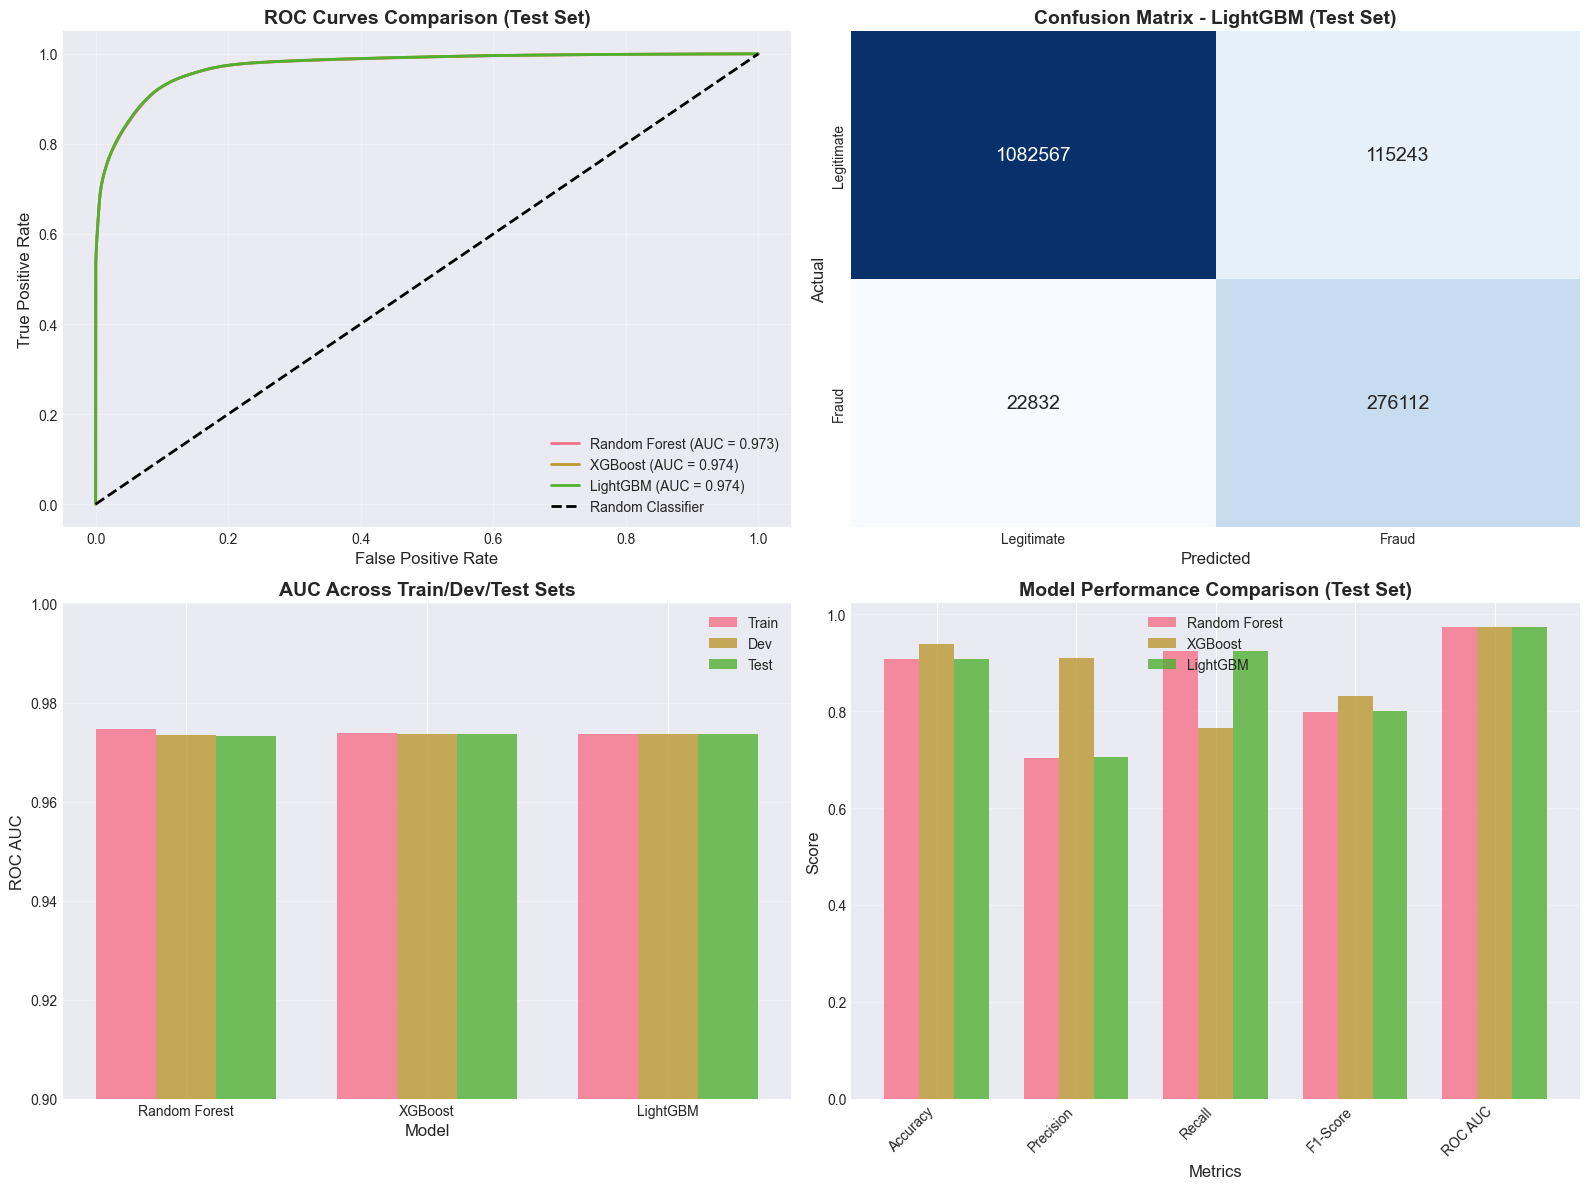


✓ Model performance visualizations saved!


In [ ]:
#Visualize model performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC Curves (Test Set)
for model_name in ['Random Forest', 'XGBoost', 'LightGBM']:
    if model_name == 'Random Forest':
        proba = rf_proba_test
    elif model_name == 'XGBoost':
        proba = xgb_proba_test
    else:
        proba = lgbm_proba_test
    
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0, 0].plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', linewidth=2)

axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
axes[0, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 0].set_title('ROC Curves Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Confusion Matrix - Best Model
cm = confusion_matrix(y_test, lgbm_pred_test)  # Assuming LightGBM is best
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False,
            annot_kws={'size': 14})
axes[0, 1].set_title(f'Confusion Matrix - LightGBM (Test Set)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Actual', fontsize=12)
axes[0, 1].set_xlabel('Predicted', fontsize=12)
axes[0, 1].set_xticklabels(['Legitimate', 'Fraud'])
axes[0, 1].set_yticklabels(['Legitimate', 'Fraud'])

# 3. AUC Comparison across Train/Dev/Test
model_names = ['Random Forest', 'XGBoost', 'LightGBM']
train_aucs = [roc_auc_score(y_train_balanced, rf_proba_train),
              roc_auc_score(y_train_balanced, xgb_proba_train),
              roc_auc_score(y_train_balanced, lgbm_proba_train)]
dev_aucs = [roc_auc_score(y_dev, rf_proba_dev),
            roc_auc_score(y_dev, xgb_proba_dev),
            roc_auc_score(y_dev, lgbm_proba_dev)]
test_aucs = [roc_auc_score(y_test, rf_proba_test),
             roc_auc_score(y_test, xgb_proba_test),
             roc_auc_score(y_test, lgbm_proba_test)]

x = np.arange(len(model_names))
width = 0.25

axes[1, 0].bar(x - width, train_aucs, width, label='Train', alpha=0.8)
axes[1, 0].bar(x, dev_aucs, width, label='Dev', alpha=0.8)
axes[1, 0].bar(x + width, test_aucs, width, label='Test', alpha=0.8)
axes[1, 0].set_xlabel('Model', fontsize=12)
axes[1, 0].set_ylabel('ROC AUC', fontsize=12)
axes[1, 0].set_title('AUC Across Train/Dev/Test Sets', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(model_names)
axes[1, 0].legend()
axes[1, 0].set_ylim(0.9, 1.0)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Metrics Comparison (Test Set)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
x = np.arange(len(metrics))
width = 0.25

rf_scores = results_df[results_df['Model']=='Random Forest'][metrics].values[0]
xgb_scores = results_df[results_df['Model']=='XGBoost'][metrics].values[0]
lgbm_scores = results_df[results_df['Model']=='LightGBM'][metrics].values[0]

axes[1, 1].bar(x - width, rf_scores, width, label='Random Forest', alpha=0.8)
axes[1, 1].bar(x, xgb_scores, width, label='XGBoost', alpha=0.8)
axes[1, 1].bar(x + width, lgbm_scores, width, label='LightGBM', alpha=0.8)
axes[1, 1].set_xlabel('Metrics', fontsize=12)
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_title('Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Model performance visualizations saved!")


FEATURE IMPORTANCE ANALYSIS

Top 15 Important Features - LightGBM:
            feature  importance
             amount        2307
   transaction_hour         807
 velocity_num_trans         611
 high_risk_merchant         443
                day         369
      amount_zscore         324
               hour         292
 distance_from_home         242
        day_of_week         129
       card_present         106
   card_not_present          49
    is_small_amount          39
           is_night          31
weekend_transaction          30
    is_large_amount          24

Top 15 Important Features - XGBoost:
           feature  importance
distance_from_home    0.453105
      card_present    0.352215
  card_not_present    0.167043
  transaction_hour    0.011452
            amount    0.005516
     amount_zscore    0.005320
              hour    0.003320
high_risk_merchant    0.000833
   is_large_amount    0.000398
          is_night    0.000251
   is_small_amount    0.000248
velocity_nu

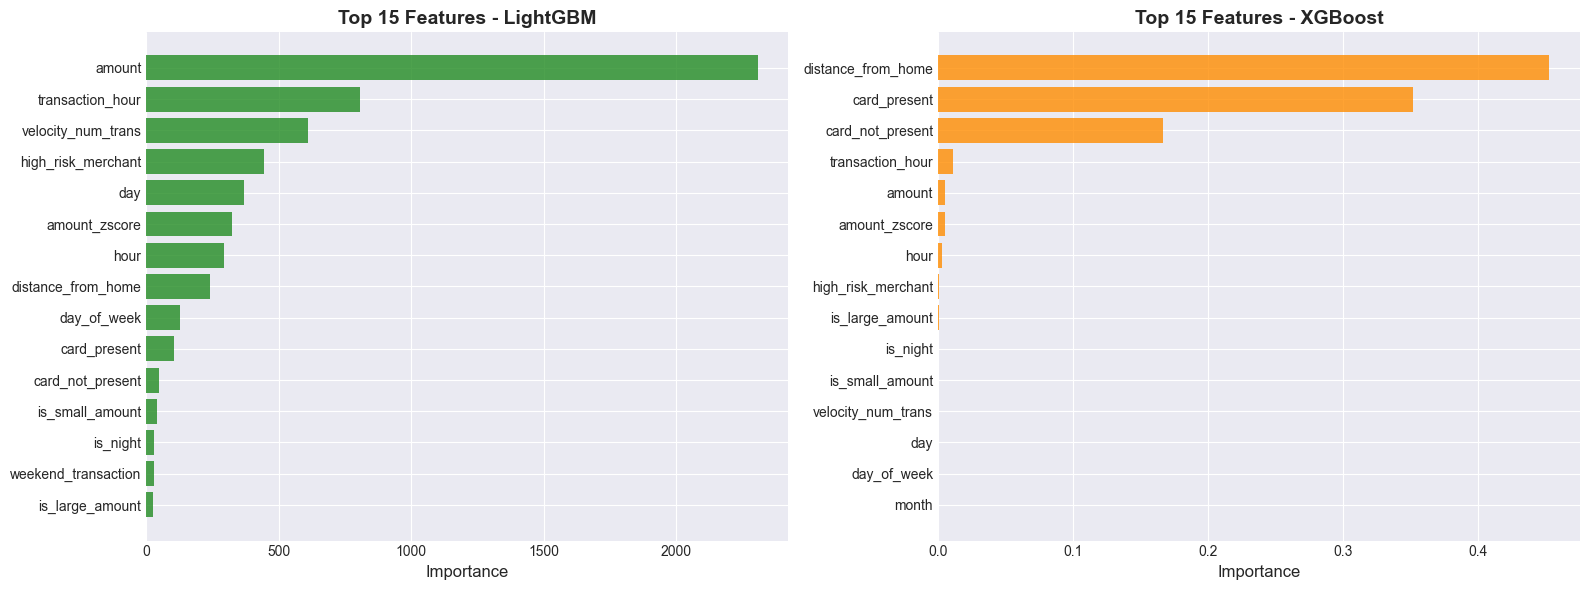


✓ Feature importance visualizations saved!


In [20]:
# Feature importance analysis
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# LightGBM feature importance (best model)
lgbm_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Display top features
print("\nTop 15 Important Features - LightGBM:")
print(lgbm_importance.head(15).to_string(index=False))

print("\nTop 15 Important Features - XGBoost:")
print(xgb_importance.head(15).to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LightGBM
top_lgbm = lgbm_importance.head(15)
axes[0].barh(range(len(top_lgbm)), top_lgbm['importance'], color='forestgreen', alpha=0.8)
axes[0].set_yticks(range(len(top_lgbm)))
axes[0].set_yticklabels(top_lgbm['feature'])
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Top 15 Features - LightGBM', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# XGBoost
top_xgb = xgb_importance.head(15)
axes[1].barh(range(len(top_xgb)), top_xgb['importance'], color='darkorange', alpha=0.8)
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['feature'])
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Top 15 Features - XGBoost', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Feature importance visualizations saved!")


In [21]:
# Save models and important objects
import pickle

print("="*60)
print("SAVING MODELS AND ARTIFACTS")
print("="*60)

# Save models
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✓ Random Forest model saved as 'random_forest_model.pkl'")

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("✓ XGBoost model saved as 'xgboost_model.pkl'")

with open('lightgbm_model.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)
print("✓ LightGBM model saved as 'lightgbm_model.pkl'")

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved as 'scaler.pkl'")

# Save label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("✓ Label encoders saved as 'label_encoders.pkl'")

# Save feature columns
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
print("✓ Feature columns saved as 'feature_columns.pkl'")

# Save results summary
results_df.to_csv('model_comparison_results.csv', index=False)
print("✓ Results summary saved as 'model_comparison_results.csv'")

print("\n" + "="*60)
print("ALL ARTIFACTS SAVED SUCCESSFULLY!")
print("="*60)


SAVING MODELS AND ARTIFACTS
✓ Random Forest model saved as 'random_forest_model.pkl'
✓ XGBoost model saved as 'xgboost_model.pkl'
✓ LightGBM model saved as 'lightgbm_model.pkl'
✓ Scaler saved as 'scaler.pkl'
✓ Label encoders saved as 'label_encoders.pkl'
✓ Feature columns saved as 'feature_columns.pkl'
✓ Results summary saved as 'model_comparison_results.csv'

ALL ARTIFACTS SAVED SUCCESSFULLY!
